## Bước 11: Error Analysis + Explainability
### 11.1 Đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/depression_severity_preprocessed.csv')
label_map = {'minimum': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
label_names = {0: 'minimum', 1: 'mild', 2: 'moderate', 3: 'severe'}
df['label_num'] = df['label'].map(label_map)

X_neural_text = df['text_neural'].values
y = df['label_num'].values

print("Số dòng:", len(df))

Số dòng: 3519


### 11.2 Load DistilBERT, lấy dự đoán chi tiết trên tập test

In [2]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.model_selection import train_test_split

# Load lại model đã lưu (không cần train lại)
model_bert = AutoModelForSequenceClassification.from_pretrained('../models/distilbert_model_tuned')
tokenizer = AutoTokenizer.from_pretrained('../models/distilbert_model_tuned')
model_bert.eval()

# Dùng đúng lại tập test đã tạo ở Bước 8 (cùng random_state=42 để tái lập chính xác)
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_neural_text, y, test_size=0.2, stratify=y, random_state=42
)

print("Số mẫu test:", len(X_test_bert))
print("Đã load xong model và tái tạo tập test")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Số mẫu test: 704
Đã load xong model và tái tạo tập test


### 11.3 Dự đoán chi tiết trên tập test

In [3]:
def tokenize_texts(texts, tokenizer, max_len=150):
    return tokenizer(list(texts), padding='max_length', truncation=True,
                      max_length=max_len, return_tensors='pt')

test_encodings = tokenize_texts(X_test_bert, tokenizer)

all_preds = []
all_probs = []
batch_size = 8

with torch.no_grad():
    for i in range(0, len(X_test_bert), batch_size):
        batch_input_ids = test_encodings['input_ids'][i:i+batch_size]
        batch_attention_mask = test_encodings['attention_mask'][i:i+batch_size]

        outputs = model_bert(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.numpy())
        all_probs.extend(probs.numpy())

# Tạo bảng kết quả chi tiết
results_detail = pd.DataFrame({
    'text': X_test_bert,
    'true_label': y_test_bert,
    'pred_label': all_preds,
})
results_detail['true_label_name'] = results_detail['true_label'].map(label_names)
results_detail['pred_label_name'] = results_detail['pred_label'].map(label_names)
results_detail['correct'] = results_detail['true_label'] == results_detail['pred_label']

print("Tổng số câu test:", len(results_detail))
print("Số câu đúng:", results_detail['correct'].sum())
print("Số câu sai:", (~results_detail['correct']).sum())
print("Accuracy:", results_detail['correct'].mean().round(4))

Tổng số câu test: 704
Số câu đúng: 529
Số câu sai: 175
Accuracy: 0.7514


### 11.4 Confusion Matrix

Confusion Matrix (hàng = nhãn thật, cột = nhãn dự đoán):
          minimum  mild  moderate  severe
minimum       429    22        40      20
mild           11    28         5      14
moderate       20    15        41       3
severe          8    11         6      31


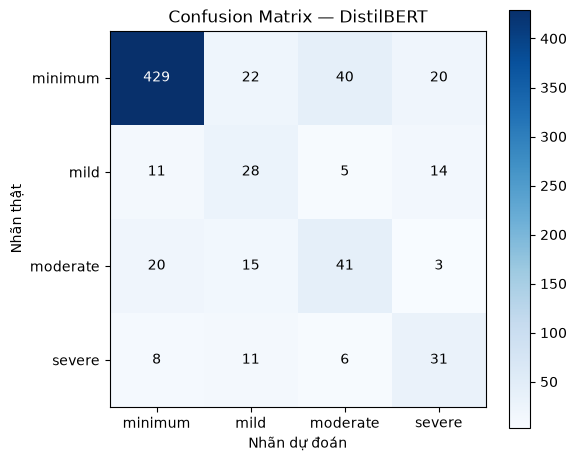

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

label_order_names = ['minimum', 'mild', 'moderate', 'severe']
cm = confusion_matrix(results_detail['true_label_name'], results_detail['pred_label_name'],
                        labels=label_order_names)

cm_df = pd.DataFrame(cm, index=label_order_names, columns=label_order_names)
print("Confusion Matrix (hàng = nhãn thật, cột = nhãn dự đoán):")
print(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(4), label_order_names)
plt.yticks(range(4), label_order_names)
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thật')
plt.title('Confusion Matrix — DistilBERT')

for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_distilbert.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.5 Trích xuất câu sai theo từng loại lỗi

In [5]:
errors = results_detail[~results_detail['correct']].copy()
print("Tổng số câu sai:", len(errors))

# Loại 1: nhầm giữa các mức liền kề (mơ hồ)
adjacent_errors = errors[abs(errors['true_label'] - errors['pred_label']) == 1]
print("\nLỗi mức liền kề (VD: mild<->moderate):", len(adjacent_errors))

# Loại 2: nhầm cách xa (2-3 mức, đáng chú ý nhất)
far_errors = errors[abs(errors['true_label'] - errors['pred_label']) >= 2]
print("Lỗi nhảy xa (2-3 mức, ví dụ mild->severe):", len(far_errors))

print("\n=== 5 ví dụ lỗi nhảy xa (đáng phân tích nhất) ===")
for idx, row in far_errors.head(5).iterrows():
    print(f"\nThật: {row['true_label_name']} | Đoán: {row['pred_label_name']}")
    print(f"Text: {row['text'][:200]}")

Tổng số câu sai: 175

Lỗi mức liền kề (VD: mild<->moderate): 62
Lỗi nhảy xa (2-3 mức, ví dụ mild->severe): 113

=== 5 ví dụ lỗi nhảy xa (đáng phân tích nhất) ===

Thật: moderate | Đoán: minimum
Text: I was a friendly person, who enjoyed speaking and interacting with people. I definitely did more than my fair share to help/get things done. And i enjoyed helping people and sharing my knowledge to he

Thật: minimum | Đoán: severe
Text: The few gal friends I associate with are either in relationships or kind of just brush me off or fake like they want to hang out but really don’t when the time comes. My school has no clubs whatsoever

Thật: minimum | Đoán: moderate
Text: When I take the time to relax and think of something nice like a waterfall or a forest or something like that I then automatically think of how bad people are going to mess it up and pollute and make 

Thật: minimum | Đoán: severe
Text: I just wanted to say thank you to everyone that posts on here. I just found this subred

### 11.6 Kiểm định giả thuyết: model nhầm từ khóa chấn thương với severe

In [6]:
trauma_words = ['abuse', 'abused', 'trauma', 'traumatic', 'horrific', 'wound', 'hospital',
                 'attack', 'assault', 'violence', 'hurt', 'injury', 'scared']

def contains_trauma_words(text):
    text_lower = text.lower()
    return any(w in text_lower for w in trauma_words)

# Trong các lỗi nhảy xa dự đoán thành severe (nhãn thật thấp hơn)
false_severe = far_errors[far_errors['pred_label'] == 3]
trauma_ratio_false_severe = false_severe['text'].apply(contains_trauma_words).mean()

# So sánh với toàn bộ tập test
trauma_ratio_all = results_detail['text'].apply(contains_trauma_words).mean()

print(f"Tỉ lệ chứa từ khóa chấn thương trong lỗi 'bị đoán nhầm thành severe': {trauma_ratio_false_severe:.2%}")
print(f"Tỉ lệ chứa từ khóa chấn thương trong toàn bộ tập test: {trauma_ratio_all:.2%}")
print(f"\nSố câu trong nhóm 'bị đoán nhầm thành severe': {len(false_severe)}")

Tỉ lệ chứa từ khóa chấn thương trong lỗi 'bị đoán nhầm thành severe': 32.35%
Tỉ lệ chứa từ khóa chấn thương trong toàn bộ tập test: 19.74%

Số câu trong nhóm 'bị đoán nhầm thành severe': 34


### 11.7 LIME — Giải thích 1 ca dự đoán sai điển hình

In [7]:
from lime.lime_text import LimeTextExplainer

label_names_list = ['minimum', 'mild', 'moderate', 'severe']

def predict_proba_bert(texts):
    all_probs = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i+batch_size])
        encodings = tokenizer(batch, padding='max_length', truncation=True,
                                max_length=150, return_tensors='pt')
        with torch.no_grad():
            outputs = model_bert(**encodings)
            probs = torch.softmax(outputs.logits, dim=1).numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)

explainer = LimeTextExplainer(class_names=label_names_list)

sample_row = false_severe.iloc[0]
sample_text_for_lime = sample_row['text']

print(f"Nhãn thật: {sample_row['true_label_name']}")
print(f"Nhãn model đoán: {sample_row['pred_label_name']}")

exp = explainer.explain_instance(sample_text_for_lime, predict_proba_bert,
                                    num_features=10, num_samples=200, labels=[3])

print("\n=== Các từ đóng góp nhiều nhất vào việc đoán 'severe' ===")
for word, weight in exp.as_list(label=3):
    print(f"  {word}: {weight:.4f}")

Nhãn thật: minimum
Nhãn model đoán: severe

=== Các từ đóng góp nhiều nhất vào việc đoán 'severe' ===
  what: 0.1667
  do: 0.1510
  to: 0.1493
  t: 0.0763
  fairly: -0.0711
  know: 0.0527
  are: -0.0494
  out: 0.0373
  can: 0.0194
  the: 0.0042


### 11.8 Lưu kết quả LIME

In [8]:
exp.save_to_file('../outputs/figures/lime_explanation_example.html')
print("Đã lưu: outputs/figures/lime_explanation_example.html")

Đã lưu: outputs/figures/lime_explanation_example.html
